In [6]:
import numpy as np

def softmax(x):
    x_max = np.max(x, axis=1, keepdims=True)
    exp_x = np.exp(x - x_max)
    return exp_x / np.sum(exp_x, axis=1, keepdims=True)

X = np.array([[1000, 2000, 3000], [2000, 3000, 1000]])
print(softmax(X))

[[0. 0. 1.]
 [0. 1. 0.]]


In [9]:
import numpy as np

def cross_entropy_loss(logits, labels):
    max_logits = np.max(logits, axis=1, keepdims=True)
    shifted_logits = logits - max_logits
    
    log_sum_exp = np.log(np.sum(np.exp(shifted_logits), axis=1, keepdims=True))
    
    loss = -np.sum(labels * (shifted_logits - log_sum_exp)) / logits.shape[0]
    return loss

logits = np.array([[0.1, 0.5, 0.1], [0.5, 0.7, 0.1]])
labels = np.array([[0, 1, 0], [0, 1, 0]])


0.8561384430573495


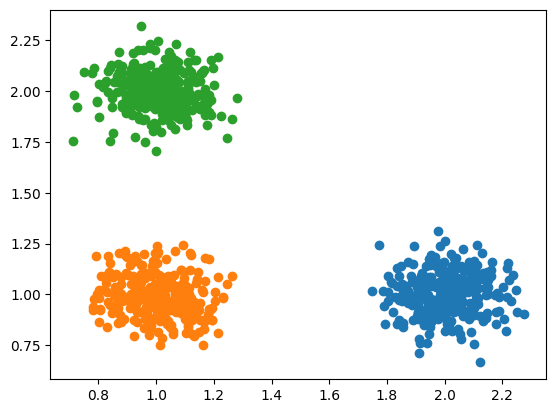

In [23]:
import matplotlib.pyplot as plt

def generate_data(n_samples=300, n_classes=3):
    centers = [[2,1], [1,1], [1,2]]
    
    X = []
    y = []
    for class_id in range(1, n_classes+1):
        X_class = np.random.randn(n_samples, 2) * 0.1 + centers[class_id-1]
        y_class = np.full(n_samples, class_id)
        
        X.extend(X_class)
        y.extend(y_class)
        
    return np.array(X), np.array(y)
        
X, y = generate_data()

n_classes = 3
fig, ax = plt.subplots()

for class_id in range(1, n_classes + 1):
    idx = y == class_id
    ax.scatter(X[idx, 0], X[idx, 1])

plt.show()

In [36]:
def compute_gradient(logits, labels):
    probs = softmax(logits)
    return (probs - labels) / len(logits)

# X, y = generate_data()
X, y = generate_spiral_data()
labels = np.eye(3)[y]

W = np.random.randn(2, 3) * 0.01
b = np.zeros(3)
lr = 0.1
for epoch in range(5000):
    logits = X @ W + b
    loss = cross_entropy_loss(logits, labels)
    
    grad_logits = compute_gradient(logits, labels)
    
    dw = X.T @ grad_logits
    db = np.sum(grad_logits, axis=0)
    
    W -= lr * dw
    b -= lr * db

    if epoch % 100 == 0:
        print(f"{epoch} loss: {loss}")
        probs = softmax(X @ W + b)
        y_pred = np.argmax(probs, axis=1)
        print(np.sum(y_pred == y))



0 loss: 1.0992160018302355
462
100 loss: 0.9097924207897101
468
200 loss: 0.8357767086018001
464
300 loss: 0.8007666494884335
461
400 loss: 0.7818604950191361
460
500 loss: 0.7706986813346154
459
600 loss: 0.7636849801479026
459
700 loss: 0.7590729264597692
458
800 loss: 0.7559343895558522
458
900 loss: 0.7537410699022173
459
1000 loss: 0.7521756781657434
461
1100 loss: 0.7510393084283582
462
1200 loss: 0.7502028426111467
462
1300 loss: 0.7495800157863867
462
1400 loss: 0.7491117897390888
463
1500 loss: 0.7487569310720157
463
1600 loss: 0.7484861403048914
463
1700 loss: 0.7482782883101368
462
1800 loss: 0.7481179433405499
461
1900 loss: 0.747993710557303
461
2000 loss: 0.7478970956825503
461
2100 loss: 0.7478217141457217
462
2200 loss: 0.7477627324127725
462
2300 loss: 0.7477164680718622
462
2400 loss: 0.7476801001690073
462
2500 loss: 0.747651457185741
462
2600 loss: 0.7476288603882323
462
2700 loss: 0.7476110071164955
462
2800 loss: 0.7475968831797205
462
2900 loss: 0.747585696659651

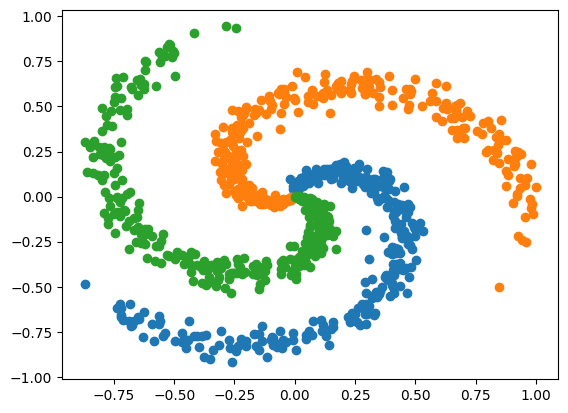

In [34]:
import matplotlib.pyplot as plt

def generate_spiral_data(num_samples=300, num_classes=3):
    X = np.zeros((num_samples*num_classes, 2))
    y = np.zeros(num_samples*num_classes, dtype=int)
    for class_id in range(num_classes):
        r = np.linspace(0, 1, num_samples)
        t = np.linspace(class_id*4, (class_id+1)*4, num_samples) + np.random.randn(num_samples)*0.2
        X[class_id*num_samples:(class_id+1)*num_samples] = np.c_[r*np.sin(t), r*np.cos(t)]
        y[class_id*num_samples:(class_id+1)*num_samples] = class_id
    return X, y

X, y = generate_spiral_data()


n_classes = 3
fig, ax = plt.subplots()

for class_id in range(n_classes):
    idx = y == class_id
    ax.scatter(X[idx, 0], X[idx, 1])

plt.show()
